# Catalog x id-supplier comparison

- Four combinations: nea-simbad, nea-emc, emc-simbad, emc-emc.
- Coverage: id / coordinate / combined matches on the full HPIC input.
- Accuracy: recall and precision against the guinea_tics gold standard.
- Goal: which combination is suitable for production.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table

from crossmatching import Crossmatcher, NEACatalog, EMCCatalog, SimbadIdSupplier, EMCIdSupplier

HPIC_FILE = "tests/data/HPIC_LC4_combined_d50_20260611.txt"
NEA_FILE  = "tests/data/pscomppars_20260611.txt"
EMC_FILE  = "exo-mercat.csv"
SIMBAD_ALT_FILE = "tests/data/alternate_ids_hpic_20260611.txt"
GOLD_FILE = "tests/data/guinea_tics.csv"

def norm(s):
    return " ".join(str(s).split())

# (label, catalog, supplier, catalog file, catalog format, alt-id file, alt format, gold expected col)
CONFIGS = [
    ("nea-simbad", NEACatalog, SimbadIdSupplier, NEA_FILE, "ascii", SIMBAD_ALT_FILE, "ascii", "nea_expected_planets"),
    ("nea-emc",    NEACatalog, EMCIdSupplier,    NEA_FILE, "ascii", EMC_FILE,        "csv",   "nea_expected_planets"),
    ("emc-simbad", EMCCatalog, SimbadIdSupplier, EMC_FILE, "csv",   SIMBAD_ALT_FILE, "ascii", "emc_expected_planets"),
    ("emc-emc",    EMCCatalog, EMCIdSupplier,    EMC_FILE, "csv",   EMC_FILE,        "csv",   "emc_expected_planets"),
]

input_table = Table.read(HPIC_FILE, format="ascii")
name_list = input_table["star_name"].tolist()
gold = Table.read(GOLD_FILE)
print(f"{len(input_table)} HPIC input stars, {len(gold)} gold-standard stars")

14571 HPIC input stars, 9 gold-standard stars


## Build one matcher per combination

- Each matcher loads its catalog and its full alternate-ID table once.
- The coordinate step depends only on the catalog, so nea-* share it and emc-* share it.

In [2]:
matchers = {}
for label, cat_cls, sup_cls, cat_file, cat_fmt, alt_file, alt_fmt, _ in CONFIGS:
    cm = Crossmatcher(cat_cls(), sup_cls())
    cm.load_catalog(from_file=cat_file, format=cat_fmt)
    cm.load_alternate_ids(name_list, from_file=alt_file)
    matchers[label] = cm
    print(f"{label:12s} catalog rows {len(cm.catalog_table):6d}   alt-id rows {len(cm.alternate_ids):7d}")

nea-simbad   catalog rows   6291   alt-id rows  279162
nea-emc      catalog rows   6291   alt-id rows     912
emc-simbad   catalog rows  16097   alt-id rows  279162
emc-emc      catalog rows  16097   alt-id rows     912


## Coverage on the full HPIC input

- Counts are unique (star, planet) pairs, so variant duplicates do not inflate them.
- combined = id matches plus coordinate matches for planets not already found by id.

In [3]:
def unique_pairs(matched, cm):
    return {(norm(s), norm(p)) for s, p in zip(matched["star_name"], matched[cm.planet_uid])}

coverage = {}
for label, *_ in CONFIGS:
    cm = matchers[label]
    id_pairs    = unique_pairs(cm.id_crossmatch(input_table, "star_name"), cm)
    coord_pairs = unique_pairs(cm.coordinate_crossmatch(input_table, "star_name"), cm)
    comb_pairs  = unique_pairs(cm.combined_crossmatch(input_table, "star_name"), cm)
    id_planets, coord_planets = {p for _, p in id_pairs}, {p for _, p in coord_pairs}
    coverage[label] = dict(
        id=len(id_pairs), coord=len(coord_pairs), combined=len(comb_pairs),
        planets=len({p for _, p in comb_pairs}), stars=len({s for s, _ in comb_pairs}),
        id_only=len(id_planets - coord_planets), coord_only=len(coord_planets - id_planets),
    )

cov_table = Table(
    rows=[(lbl, c["id"], c["coord"], c["combined"], c["planets"], c["stars"], c["id_only"], c["coord_only"])
          for lbl, c in coverage.items()],
    names=["config", "id matches", "coord matches", "combined",
           "unique planets", "unique stars", "id-only planets", "coord-only planets"],
)
cov_table

config,id matches,coord matches,combined,unique planets,unique stars,id-only planets,coord-only planets
str10,int64,int64,int64,int64,int64,int64,int64
nea-simbad,806,851,857,851,535,0,51
nea-emc,723,851,862,851,535,0,139
emc-simbad,1079,1196,1204,1196,715,0,125
emc-emc,1216,1196,1227,1196,723,0,11


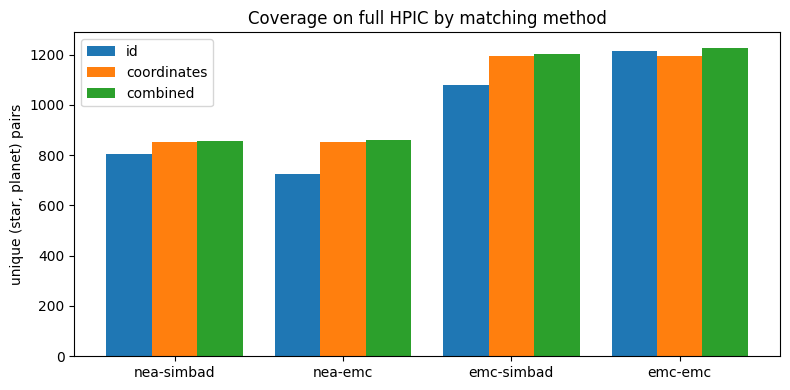

In [4]:
labels = [c[0] for c in CONFIGS]
x = np.arange(len(labels))
w = 0.27

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x - w, [coverage[l]["id"] for l in labels],       w, label="id")
ax.bar(x,     [coverage[l]["coord"] for l in labels],    w, label="coordinates")
ax.bar(x + w, [coverage[l]["combined"] for l in labels], w, label="combined")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("unique (star, planet) pairs")
ax.set_title("Coverage on full HPIC by matching method")
ax.legend()
plt.tight_layout()
plt.show()

## ID vs coordinate coverage

- id-only planets is 0 for every config: at the planet level the coordinate step is a superset of the id step.
- So the id step never discovers a new planet here; its value is precise name-based attribution.
- coord-only planets shows how much the id step misses and leaves to the coordinate fallback.
- emc-emc leaves the fewest planets to coordinates (id matching is nearly complete).

## Accuracy against the gold standard

- guinea_tics has per-catalog expected planet lists (NEA names vs EMC names).
- Run combined_crossmatch one star at a time, mirroring the e2e suite.
- recall = found expected / all expected; precision = correct found / all found (project definition in e2e_utils).

In [5]:
from collections import defaultdict

def expected_set(row, col):
    return {norm(p) for p in str(row[col]).split("|") if norm(p)}

gold_names = gold["star_name"].tolist()
gold_query = Table({"star_name": gold_names,
                    "ra": gold["ra"].astype(float),
                    "dec": gold["dec"].astype(float)})

accuracy = {}
for label, cat_cls, sup_cls, cat_file, cat_fmt, alt_file, alt_fmt, exp_col in CONFIGS:
    cm = matchers[label]
    # Reload alt-ids for exactly the gold names (with from_file), mirroring the e2e suite,
    # so the per-call cache covers them without a from_file-less reload.
    cm.load_alternate_ids(gold_names, from_file=alt_file)
    result = cm.combined_crossmatch(gold_query, "star_name")
    matched_by_star = defaultdict(set)
    for s, p in zip(result["star_name"], result[cm.planet_uid]):
        matched_by_star[norm(s)].add(norm(p))

    tp = fp = fn = 0
    for row in gold:
        expected = expected_set(row, exp_col)
        matched = matched_by_star.get(norm(row["star_name"]), set())
        tp += len(matched & expected)
        fp += len(matched - expected)
        fn += len(expected - matched)
    recall    = tp / (tp + fn) if (tp + fn) else 0.0
    precision = tp / (tp + fp) if (tp + fp) else 0.0
    f1 = 2 * recall * precision / (recall + precision) if (recall + precision) else 0.0
    accuracy[label] = dict(tp=tp, fp=fp, fn=fn, recall=recall, precision=precision, f1=f1)

acc_table = Table(
    rows=[(lbl, a["tp"], a["fp"], a["fn"], round(a["recall"], 3), round(a["precision"], 3), round(a["f1"], 3))
          for lbl, a in accuracy.items()],
    names=["config", "TP", "FP", "FN", "recall", "precision", "F1"],
)
acc_table

config,TP,FP,FN,recall,precision,F1
str10,int64,int64,int64,float64,float64,float64
nea-simbad,19,0,0,1.0,1.0,1.0
nea-emc,19,0,0,1.0,1.0,1.0
emc-simbad,28,0,0,1.0,1.0,1.0
emc-emc,28,0,0,1.0,1.0,1.0


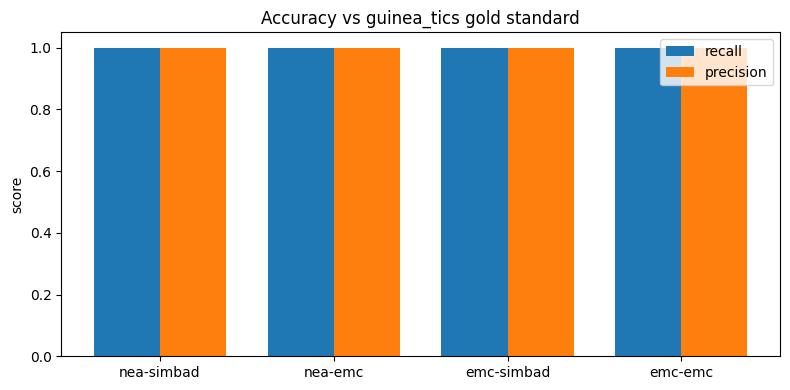

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
w = 0.38
ax.bar(x - w/2, [accuracy[l]["recall"] for l in labels],    w, label="recall")
ax.bar(x + w/2, [accuracy[l]["precision"] for l in labels], w, label="precision")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0, 1.05)
ax.set_ylabel("score")
ax.set_title("Accuracy vs guinea_tics gold standard")
ax.legend()
plt.tight_layout()
plt.show()

## Recommendation

Accuracy:
- All four configs score recall 1.0 and precision 1.0 on the 9 gold stars.
- The gold standard is too small and too clean to separate the configs; coverage is the deciding axis.

Catalog (the bigger lever):
- EMC covers far more planets than NEA (about 1196 vs 851 unique), because the EMC catalog has 16097 rows vs NEA 6291.
- Choose the catalog by which planet list you want to enrich, not by match quality.

Id-supplier, given a catalog:
- EMC catalog: emc-emc gives the most matches (1227 combined) and the most precise id step (only 11 planets fall back to coordinates vs 125 for emc-simbad). It also needs no SIMBAD network call.
- NEA catalog: nea-simbad and nea-emc are close (857 vs 862 combined). nea-emc leaves more planets to the coordinate fallback (139 vs 51), so its id attribution is weaker; nea-simbad is the safer NEA pairing.

Bottom line:
- emc-emc for maximum, offline, precisely-attributed coverage.
- nea-simbad as the NEA-based pipeline when NEA planet names or columns are required.
- The id step adds no planets over coordinates here, so dropping it would not lose coverage, only attribution precision and the id/coordinate cross-check.

Caveats:
- Coverage is raw match count. Correctness is validated only on the 9 gold stars, where all configs are perfect. So the recommendation rests on coverage plus offline operation, not on demonstrated at-scale precision.
- id-only planets being 0 holds at the default `Crossmatcher()` radii (10 arcsec, 50 arcsec when proper motion or epoch is unknown). A tighter coordinate radius would let the id step recover planets coordinates miss, and the no-coverage-lost claim would flip.
- A precision proxy that separates the configs at scale is the id-vs-coordinate attribution-agreement check from `companion_mismatch.ipynb`.